# COGNIFYZ TECHNOLOGIES - DATA SCIENCE INTERNSHIP
## LEVEL 3: Tasks 1, 2 and 3

**Dataset:** Zomato Restaurant Dataset

This notebook is the Jupyter version of the supplied Level 3 code. `Dataset.csv` should be in the same folder as this notebook.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [3]:
BASE_DIR = Path.cwd()
FILE = BASE_DIR / "Dataset.csv"

if not FILE.exists():
    raise FileNotFoundError(
        f"Dataset.csv was not found in: {BASE_DIR}\n"
        "Please place Dataset.csv in the same folder as this notebook."
    )

# Try UTF-8 first; latin1 handles many Zomato CSV files saved with non-UTF-8 characters.
try:
    df = pd.read_csv(FILE, encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(FILE, encoding="latin1")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print("File:", FILE)
print("Rows and columns:", df.shape)
print("\nOriginal columns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

DATASET LOADED SUCCESSFULLY
File: c:\Internship\Cognifyz_Data_Science_Project\Level_3\Dataset.csv
Rows and columns: (9551, 27)

Original columns:
['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address', 'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average_Cost_for_two', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Aggregate_rating', 'Rating_color', 'Rating_text', 'Votes', 'Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count', 'Has_Table_Booking_Encoded', 'Has_Online_Delivery_Encoded', 'Votes_per_Rating_Point']

First 5 rows:


,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,Average_Cost_for_two,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes,Restaurant_Name_Length,Address_Length,Cuisine_Count,Has_Table_Booking_Encoded,Has_Online_Delivery_Encoded,Votes_per_Rating_Point
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,16,71,3,1,0,65.416667
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,16,67,1,1,0,131.333333
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,22,56,4,1,0,61.363636
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,4,70,2,0,0,74.489796
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,11,64,2,1,0,47.708333


## 3. Standardize Column Names and Convert Numerical Columns

In [4]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_")
      .str.replace("/", "_")
      .str.replace("(", "", regex=False)
      .str.replace(")", "", regex=False)
)

for col in ["Aggregate_rating", "Votes", "Price_range",
            "Latitude", "Longitude", "Country_Code"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df = df.drop_duplicates().copy()

print("Duplicate rows removed:", before - len(df))
print("Rows after preprocessing:", len(df))
print("\nStandardized columns:")
print(df.columns.tolist())

Duplicate rows removed: 0
Rows after preprocessing: 9551

Standardized columns:
['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address', 'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average_Cost_for_two', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Aggregate_rating', 'Rating_color', 'Rating_text', 'Votes', 'Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count', 'Has_Table_Booking_Encoded', 'Has_Online_Delivery_Encoded', 'Votes_per_Rating_Point']


# TASK 1: CUSTOMER PREFERENCE ANALYSIS

## 4. Top Cuisines by Total Customer Votes

Top 15 cuisines by total votes:


,Total_Votes
Cuisines,
North Indian,595981
Chinese,364351
Italian,329265
Continental,288255
Fast Food,184058
American,183117
Cafe,177568
Mughlai,151946
Desserts,105889


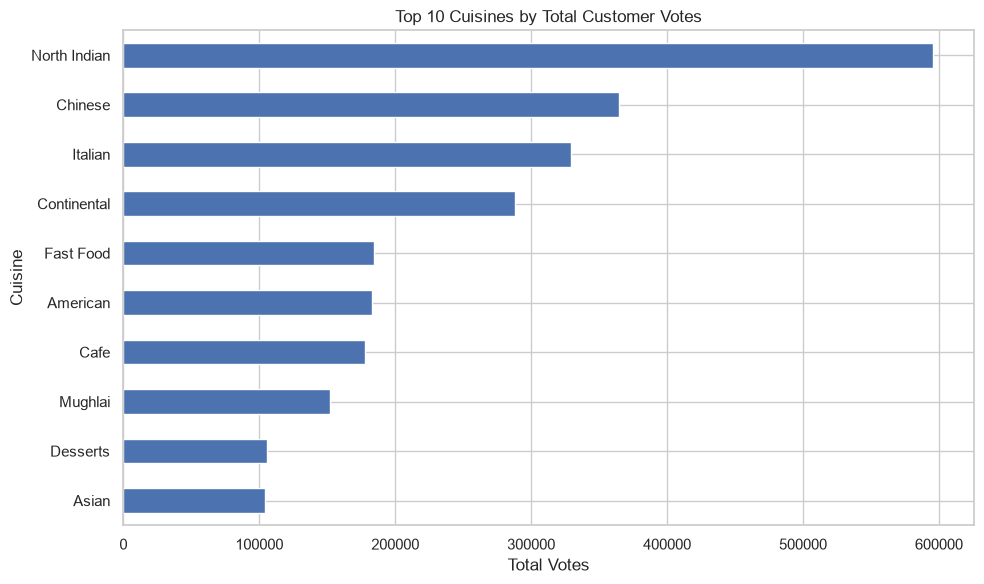

In [5]:
if {"Cuisines", "Votes"}.issubset(df.columns):
    cuisine_votes = (
        df[["Cuisines", "Votes"]]
        .dropna()
        .assign(Cuisines=lambda x: x["Cuisines"].astype(str).str.split(","))
        .explode("Cuisines")
    )
    cuisine_votes["Cuisines"] = cuisine_votes["Cuisines"].str.strip()

    cuisine_restaurants = cuisine_votes["Cuisines"].value_counts()
    popular_cuisines = (
        cuisine_votes.groupby("Cuisines")["Votes"]
        .sum()
        .sort_values(ascending=False)
    )

    print("Top 15 cuisines by total votes:")
    display(popular_cuisines.head(15).to_frame("Total_Votes"))

    plt.figure(figsize=(10, 6))
    popular_cuisines.head(10).sort_values().plot(kind="barh")
    plt.title("Top 10 Cuisines by Total Customer Votes")
    plt.xlabel("Total Votes")
    plt.ylabel("Cuisine")
    plt.tight_layout()
    plt.show()
else:
    print("Cuisines or Votes column not found.")

## 5. Cuisines by Average Rating

Top cuisines by average rating (minimum 20 records):


,count,mean
Cuisines,,
International,21,4.248
Southern,24,4.129
Vegetarian,23,4.074
Sandwich,53,4.066
Grill,21,4.057
Steak,62,3.985
Sushi,75,3.973
Goan,20,3.970
Breakfast,41,3.966


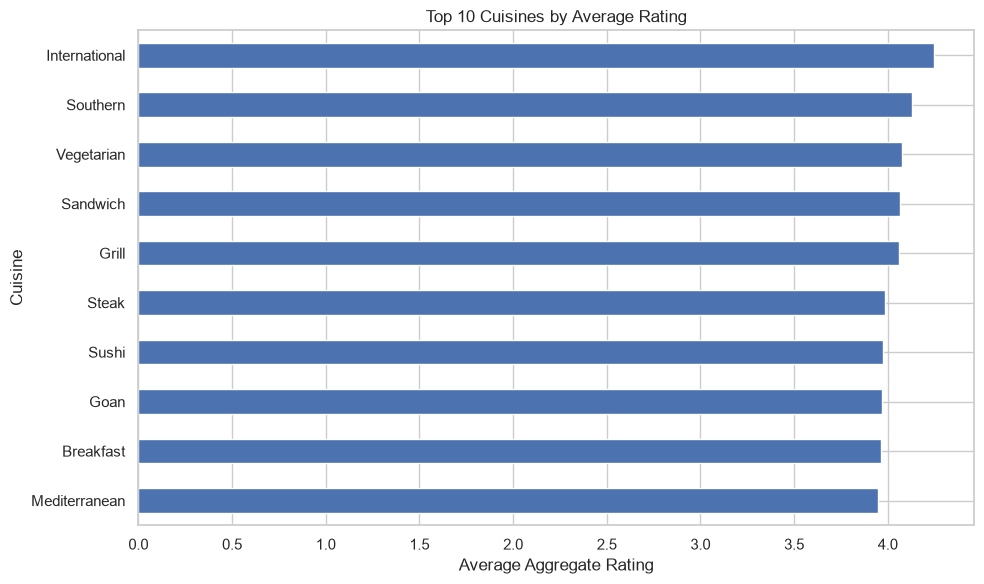

In [6]:
if {"Cuisines", "Aggregate_rating"}.issubset(df.columns):
    cuisine_rating = (
        df[["Cuisines", "Aggregate_rating"]]
        .dropna()
        .assign(Cuisines=lambda x: x["Cuisines"].astype(str).str.split(","))
        .explode("Cuisines")
    )
    cuisine_rating["Cuisines"] = cuisine_rating["Cuisines"].str.strip()

    rating_by_cuisine = (
        cuisine_rating.groupby("Cuisines")["Aggregate_rating"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )
    reliable_rating = rating_by_cuisine[rating_by_cuisine["count"] >= 20]

    print("Top cuisines by average rating (minimum 20 records):")
    display(reliable_rating.head(15).round(3))

    plt.figure(figsize=(10, 6))
    reliable_rating.head(10)["mean"].sort_values().plot(kind="barh")
    plt.title("Top 10 Cuisines by Average Rating")
    plt.xlabel("Average Aggregate Rating")
    plt.ylabel("Cuisine")
    plt.tight_layout()
    plt.show()
else:
    print("Cuisines or Aggregate_rating column not found.")

# TASK 2: DATA VISUALIZATION

## 6. Distribution of Aggregate Ratings

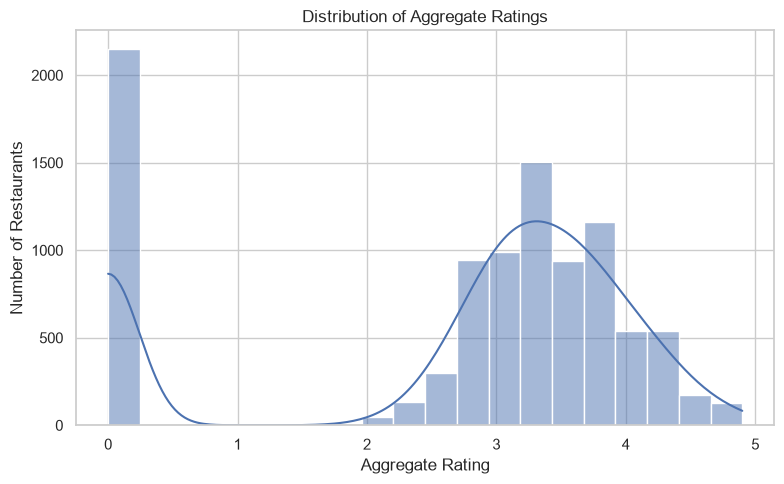

In [7]:
if "Aggregate_rating" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["Aggregate_rating"].dropna(), bins=20, kde=True)
    plt.title("Distribution of Aggregate Ratings")
    plt.xlabel("Aggregate Rating")
    plt.ylabel("Number of Restaurants")
    plt.tight_layout()
    plt.show()

## 7. Restaurant Rating Counts

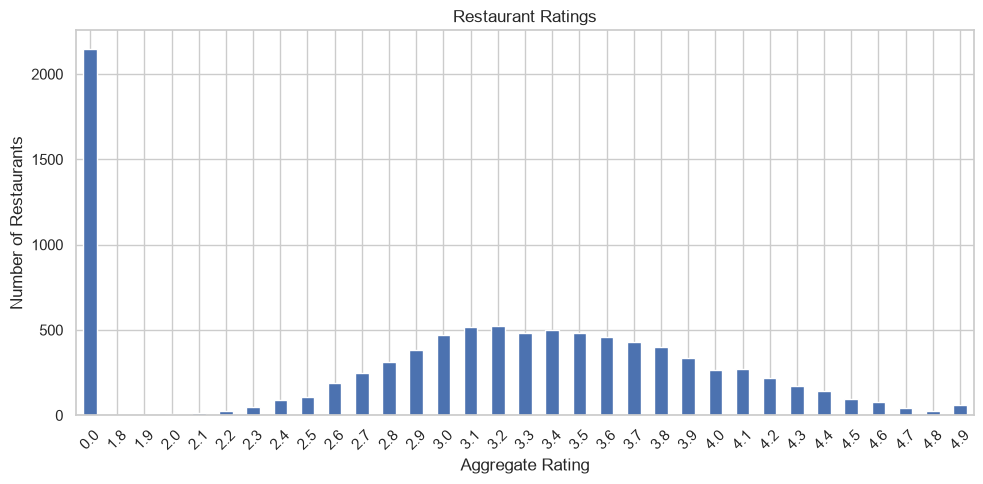

In [8]:
if "Aggregate_rating" in df.columns:
    rating_counts = df["Aggregate_rating"].round(1).value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    rating_counts.plot(kind="bar")
    plt.title("Restaurant Ratings")
    plt.xlabel("Aggregate Rating")
    plt.ylabel("Number of Restaurants")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Top Cities by Average Rating

Top cities by average rating (minimum 20 restaurants):


,count,mean
City,,
London,20,4.535
Orlando,20,4.475
Rest of Hawaii,20,4.410
Tampa Bay,20,4.410
Bangalore,20,4.375
Dubai,20,4.370
Chennai,20,4.315
Ankara,20,4.305
Abu Dhabi,20,4.300


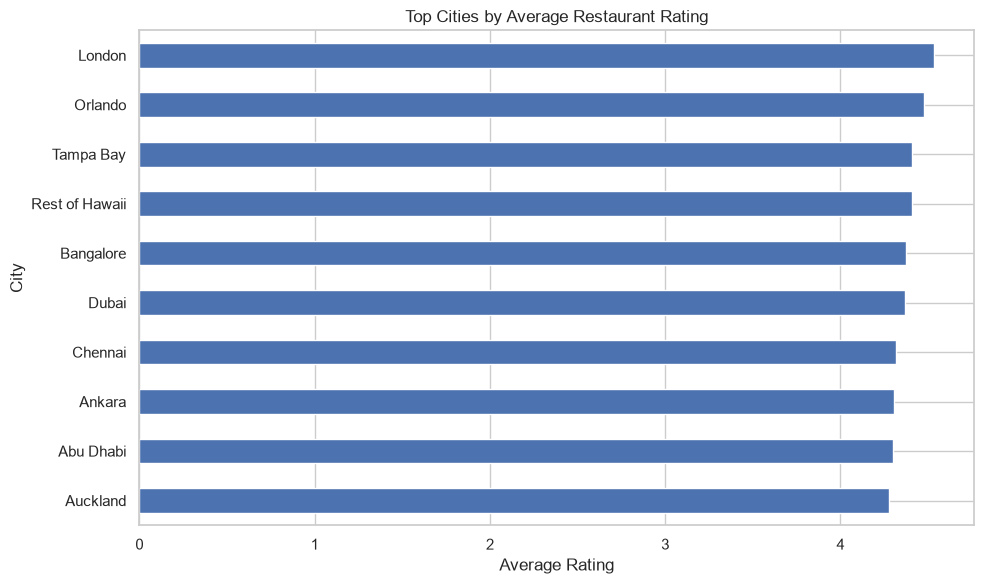

In [9]:
if {"City", "Aggregate_rating"}.issubset(df.columns):
    city_stats = df.groupby("City")["Aggregate_rating"].agg(["count", "mean"])
    city_stats = city_stats[city_stats["count"] >= 20]
    city_stats = city_stats.sort_values("mean", ascending=False).head(10)

    print("Top cities by average rating (minimum 20 restaurants):")
    display(city_stats.round(3))

    plt.figure(figsize=(10, 6))
    city_stats["mean"].sort_values().plot(kind="barh")
    plt.title("Top Cities by Average Restaurant Rating")
    plt.xlabel("Average Rating")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()

## 9. Votes vs Aggregate Rating

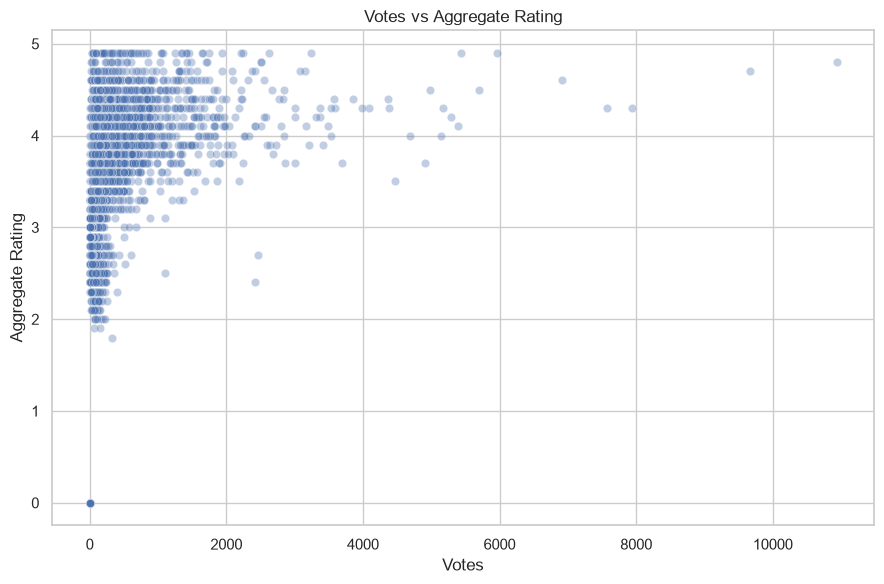

Correlation between Votes and Aggregate Rating:


,Votes,Aggregate_rating
Votes,1.000,0.314
Aggregate_rating,0.314,1.000


In [10]:
if {"Votes", "Aggregate_rating"}.issubset(df.columns):
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=df, x="Votes", y="Aggregate_rating", alpha=0.35)
    plt.title("Votes vs Aggregate Rating")
    plt.xlabel("Votes")
    plt.ylabel("Aggregate Rating")
    plt.tight_layout()
    plt.show()

    print("Correlation between Votes and Aggregate Rating:")
    display(df[["Votes", "Aggregate_rating"]].corr().round(3))

## 10. Price Range vs Aggregate Rating

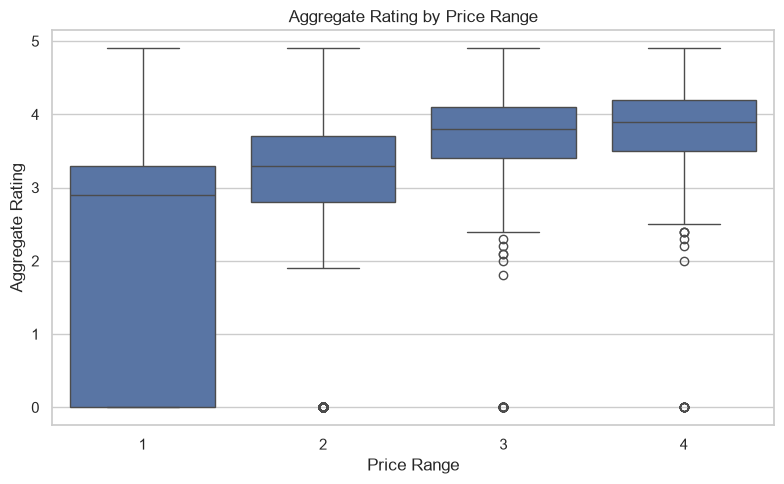

In [11]:
if {"Price_range", "Aggregate_rating"}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="Price_range", y="Aggregate_rating")
    plt.title("Aggregate Rating by Price Range")
    plt.xlabel("Price Range")
    plt.ylabel("Aggregate Rating")
    plt.tight_layout()
    plt.show()

## 11. Correlation Heatmap

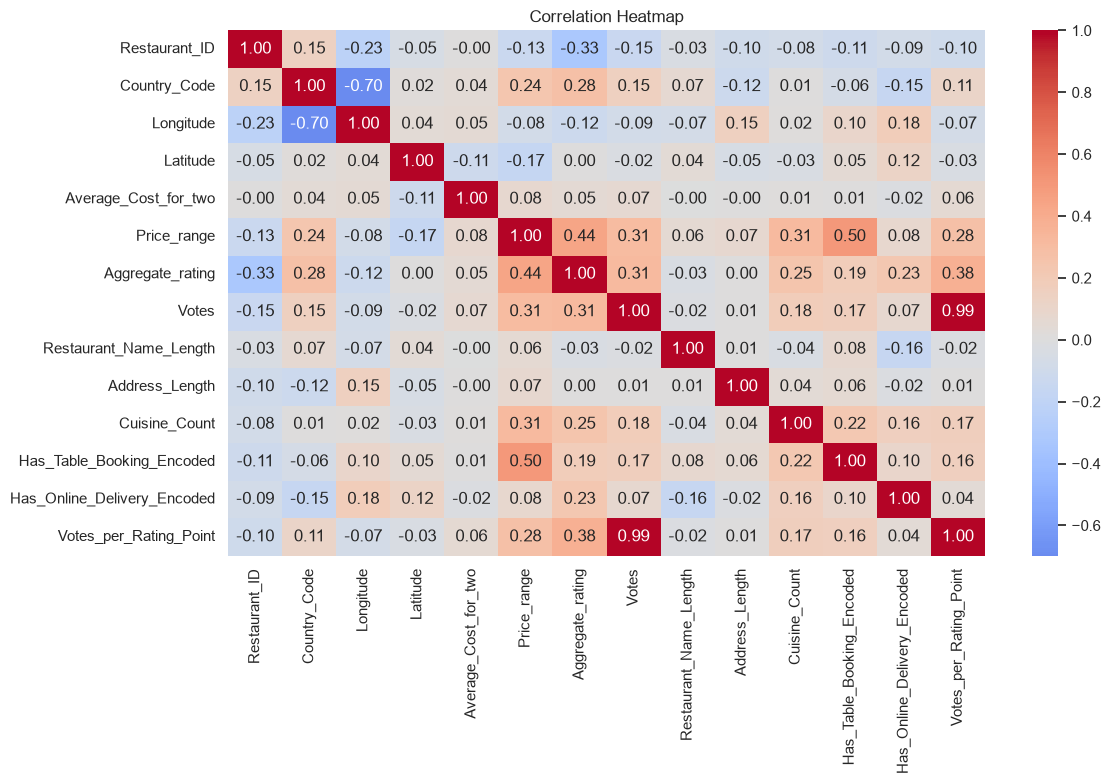

In [12]:
numeric_df = df.select_dtypes(include=np.number)

if len(numeric_df.columns) >= 2:
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# TASK 3: PREDICTIVE MODELING

## 12. Feature Engineering

In [13]:
target = "Aggregate_rating"

if target not in df.columns:
    raise ValueError("Aggregate_rating column was not found.")

preferred_features = [
    "Country_Code", "City", "Latitude", "Longitude", "Votes",
    "Price_range", "Has_Table_booking", "Has_Online_delivery",
    "Restaurant_Name_Length", "Address_Length", "Cuisine_Count"
]

if "Restaurant_Name" in df.columns and "Restaurant_Name_Length" not in df.columns:
    df["Restaurant_Name_Length"] = (
        df["Restaurant_Name"].fillna("").astype(str).str.len()
    )

if "Address" in df.columns and "Address_Length" not in df.columns:
    df["Address_Length"] = (
        df["Address"].fillna("").astype(str).str.len()
    )

if "Cuisines" in df.columns and "Cuisine_Count" not in df.columns:
    df["Cuisine_Count"] = (
        df["Cuisines"].fillna("").astype(str)
        .apply(lambda x: len([c for c in x.split(",") if c.strip()]))
    )

features = [c for c in preferred_features if c in df.columns]

if len(features) < 2:
    raise ValueError("Not enough usable predictor columns were found.")

model_df = df[features + [target]].copy()
model_df = model_df.dropna(subset=[target])

X = model_df[features]
y = model_df[target]

print("Features used:")
print(features)
print("\nNumber of observations:", len(model_df))

Features used:
['Country_Code', 'City', 'Latitude', 'Longitude', 'Votes', 'Price_range', 'Has_Table_booking', 'Has_Online_delivery', 'Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count']

Number of observations: 9551


## 13. Train-Test Split and Preprocessing

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Numeric features: ['Country_Code', 'Latitude', 'Longitude', 'Votes', 'Price_range', 'Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count']
Categorical features: ['City', 'Has_Table_booking', 'Has_Online_delivery']
Training observations: 7640
Testing observations: 1911


C:\Windows\Temp\ipykernel_2916\3525870432.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


## 14. Train and Compare Regression Models

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42, max_depth=12, min_samples_leaf=5
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1,
        max_depth=20, min_samples_leaf=2
    )
}

results = []
predictions = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name, "MAE": mae, "RMSE": rmse, "R2": r2
    })
    predictions[name] = pred

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("MODEL COMPARISON:")
display(results_df.round(4))

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model based on lowest RMSE: {best_model_name}")

MODEL COMPARISON:


,Model,MAE,RMSE,R2
0,Random Forest,0.2008,0.3045,0.9593
1,Decision Tree,0.2212,0.3331,0.9512
2,Linear Regression,1.0066,1.2247,0.3410



Best model based on lowest RMSE: Random Forest


## 15. Model Comparison

<Figure size 900x500 with 0 Axes>

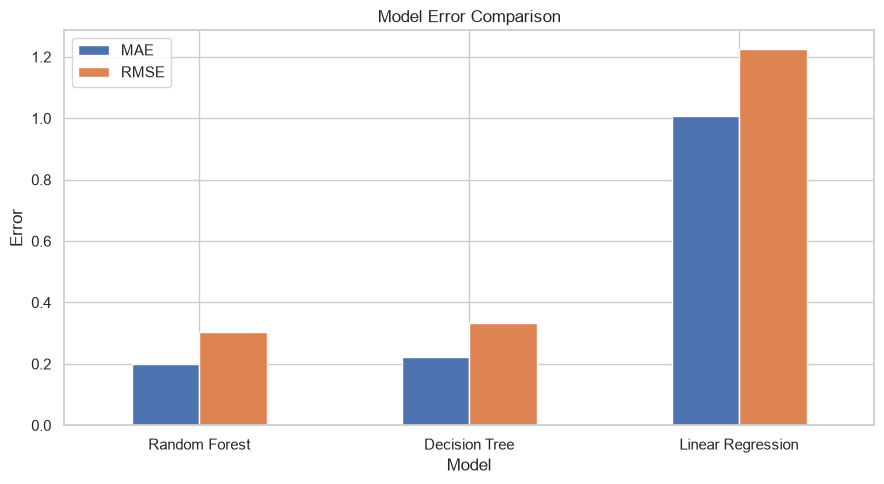

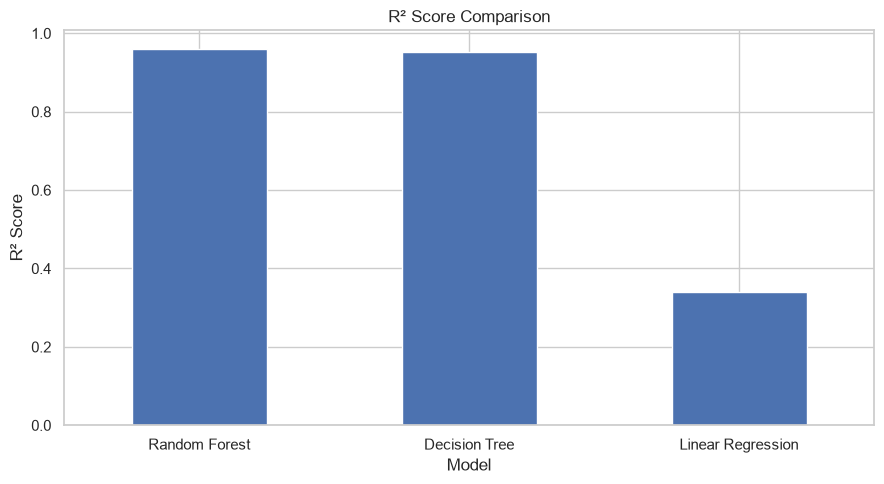

In [16]:
plt.figure(figsize=(9, 5))
results_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Error Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
results_df.set_index("Model")["R2"].plot(kind="bar", figsize=(9, 5))
plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Actual vs Predicted Ratings

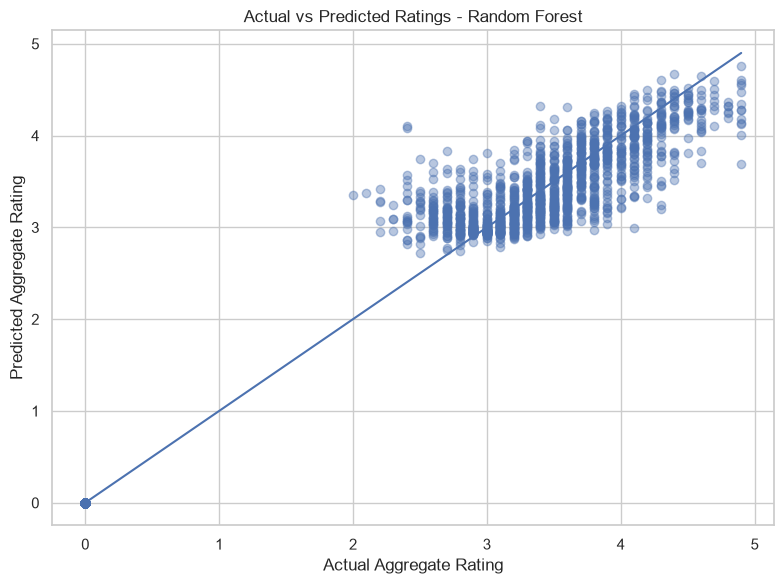

In [17]:
best_pred = predictions[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.4)

min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())

plt.plot([min_value, max_value], [min_value, max_value])
plt.title(f"Actual vs Predicted Ratings - {best_model_name}")
plt.xlabel("Actual Aggregate Rating")
plt.ylabel("Predicted Aggregate Rating")
plt.tight_layout()
plt.show()

## 17. Residual Plot

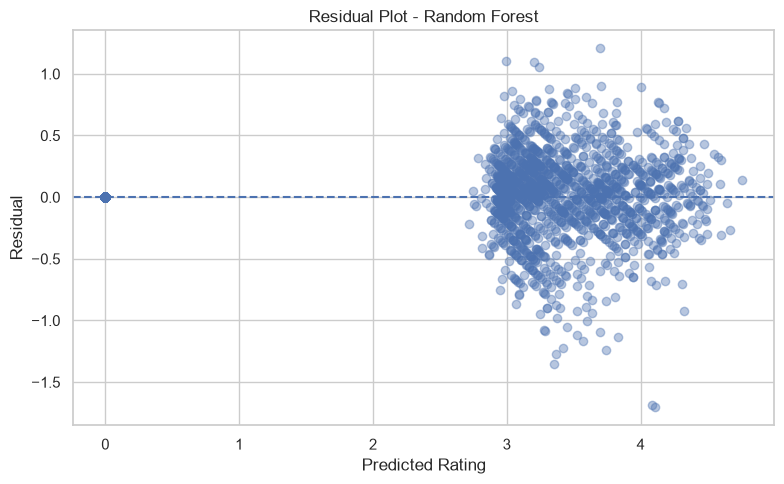

In [18]:
residuals = y_test - best_pred

plt.figure(figsize=(8, 5))
plt.scatter(best_pred, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted Rating")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

## 18. Save Model Results

In [19]:
OUTPUT_FILE = BASE_DIR / "Level_3_Model_Results.csv"
results_df.to_csv(OUTPUT_FILE, index=False)
print("Saved:", OUTPUT_FILE)

Saved: c:\Internship\Cognifyz_Data_Science_Project\Level_3\Level_3_Model_Results.csv


# LEVEL 3 COMPLETE ✅

Tasks completed:
- Customer preference analysis
- Data visualization
- Predictive modeling
- Linear Regression, Decision Tree and Random Forest comparison
- Best model selected using lowest RMSE
- Model results saved as `Level_3_Model_Results.csv`